In [1]:
import numpy as np
import matplotlib.pyplot as plt

I har bygget en drone, men efter et par testflyvninger oplever I problemer
med overophedning af den ene del. I laver nogle forsøg og når frem til følgende
temperaturmålinger for de givne tidsrum efter start ved rumtemperatur:

| tid (min) | 2.0 | 6.0 | 9.0 | 11.0 | 12.0 |
| ---- | ---- | ---- | ---- | ---- | ---- |
| temperatur (°C) | 25.0 | 35.0 | 50.0 | 65.0 | 70.0 |

$\pagebreak$

## (a) {-}
Plot grafen svarende til de overstående datapunkter.

Text(0, 0.5, 'Temperatur [°C]')

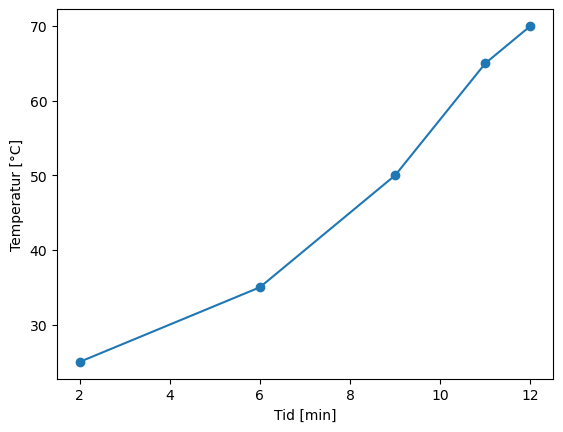

In [2]:
data = np.array([   [2, 6, 9, 11, 12],
                    [25, 35, 50, 65, 70]], dtype=float)

fig, ax = plt.subplots()
ax.plot(data[0], data[1], marker = 'o')
ax.set_xlabel('Tid [min]')
ax.set_ylabel('Temperatur [°C]')

$\pagebreak$

## (b) {-}

I vil gerne have et godt estimat for hvornår temperaturen passer 55 °C, som er den maksimale anbefalet arbejdstemperatur for nogle af komponenterne. Ved at forbinde efterfølgende punkter med rette linjer får man en simpel model for temperaturudviklingen, men denne model er ikke så realistisk, da den har knæk ved datapunkterne. Det kunne være bedre at bruge nogle polynomier.

Betragt polynomiet $p(x) = a + bx + cx^{2}$. Opstil et lineært ligningssystem
for at $p$ går igennem de sidste tre datapunkter. Løs ligningssystemet ved
hjælp af elementære rækkeoperationer. Plot resultatet.

In [3]:
# Opstiller ligningssystemet på formen [a, bx, cx² | p(x)]
ligning_3 = np.vander(data[0,2:], 3, increasing=True)
ligning_3 = np.column_stack((ligning_3, data[1,2:]))
print(ligning_3)

[[  1.   9.  81.  50.]
 [  1.  11. 121.  65.]
 [  1.  12. 144.  70.]]


In [4]:
# Udfører rækkeoperationer for at få ligningen ned på echelonform

ligning_3[1, :] -= ligning_3[0, :]
print("R1 -> R1 - R0\n", ligning_3, '\n')

ligning_3[1, :] *= 1/ligning_3[1,1]
print("R1 -> 1/2 * R1\n", ligning_3, '\n')

ligning_3[2, :] -= ligning_3[0, :]
print("R2 -> R2 - R0\n", ligning_3, '\n')

ligning_3[2, :] -= 3 * ligning_3[1, :]
print("R2 -> 3 * R1\n", ligning_3, '\n')

ligning_3[2, :] *= 1/ligning_3[2,2]
print("R2 -> 1/3 * R2\n", ligning_3, '\n')

ligning_3[1, :] -= 20 * ligning_3[2, :]
print("R1 -> R1 - 20 * R2\n", ligning_3, '\n')

ligning_3[0, :] -= 9 * ligning_3[1, :]
print("R0 -> R1 - 9 * R1\n", ligning_3, '\n')

ligning_3[0, :] -= 81 * ligning_3[2, :]
print("R0 -> 81 * R2\n", ligning_3)

R1 -> R1 - R0
 [[  1.   9.  81.  50.]
 [  0.   2.  40.  15.]
 [  1.  12. 144.  70.]] 

R1 -> 1/2 * R1
 [[  1.    9.   81.   50. ]
 [  0.    1.   20.    7.5]
 [  1.   12.  144.   70. ]] 

R2 -> R2 - R0
 [[ 1.   9.  81.  50. ]
 [ 0.   1.  20.   7.5]
 [ 0.   3.  63.  20. ]] 

R2 -> 3 * R1
 [[ 1.   9.  81.  50. ]
 [ 0.   1.  20.   7.5]
 [ 0.   0.   3.  -2.5]] 

R2 -> 1/3 * R2
 [[ 1.          9.         81.         50.        ]
 [ 0.          1.         20.          7.5       ]
 [ 0.          0.          1.         -0.83333333]] 

R1 -> R1 - 20 * R2
 [[ 1.          9.         81.         50.        ]
 [ 0.          1.          0.         24.16666667]
 [ 0.          0.          1.         -0.83333333]] 

R0 -> R1 - 9 * R1
 [[   1.            0.           81.         -167.5       ]
 [   0.            1.            0.           24.16666667]
 [   0.            0.            1.           -0.83333333]] 

R0 -> 81 * R2
 [[   1.            0.            0.         -100.        ]
 [   0.            

In [5]:
# Tildeler koefficienterne løsningsværdier fra ligningen på echelonform
a, b, c = ligning_3[:, -1]
print(f"a = {a}, b = {b}, c = {c}")

a = -99.99999999999997, b = 24.166666666666664, c = -0.8333333333333333


$\pagebreak$

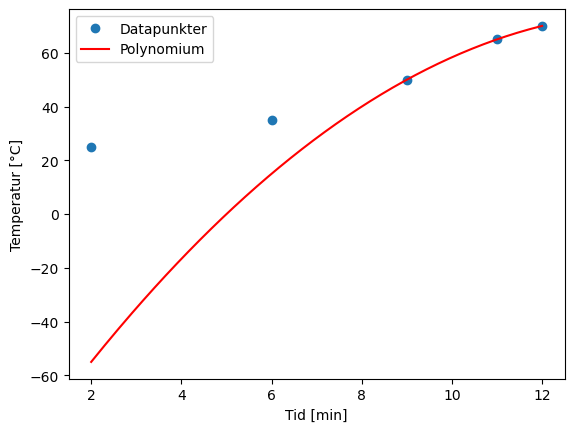

In [6]:
# Opstiller polynomiets x- og y-værdier
n = 200
x = np.linspace(2, 12, n)
y = a + b * x + c * x**2

fig, ax = plt.subplots()
ax.plot(data[0], data[1], 'o', label = 'Datapunkter')
ax.plot(x, y, color = 'red', label = 'Polynomium')
ax.set_xlabel('Tid [min]')
ax.set_ylabel('Temperatur [°C]')
ax.legend()

$\pagebreak$

## (c) {-}

Hvis man vil have et polynomium $p(x)$ der går igennem alle 5 datapunkter, hvad er den mindst mulige grad for $p(x)$? Bestem sådan et polynomium, denne gang må I bruge np.linalg.solve(), og plot resultatet.

Da der er 5 ligninger er der nødt til at være 5 tilsvarende ubekendte. Det skal da mindst være et 4. grads polynomium på formen:
$$
p(x) = a + bx + cx^{2} + dx^{3} + ex^{4}
$$

In [7]:
# Opstiller ligningssystemet som før
ligning_5 = np.vander(data[0,:], 5, increasing=True)
ligning_5 = np.column_stack((ligning_5, data[1,:]))
print(ligning_5)

[[1.0000e+00 2.0000e+00 4.0000e+00 8.0000e+00 1.6000e+01 2.5000e+01]
 [1.0000e+00 6.0000e+00 3.6000e+01 2.1600e+02 1.2960e+03 3.5000e+01]
 [1.0000e+00 9.0000e+00 8.1000e+01 7.2900e+02 6.5610e+03 5.0000e+01]
 [1.0000e+00 1.1000e+01 1.2100e+02 1.3310e+03 1.4641e+04 6.5000e+01]
 [1.0000e+00 1.2000e+01 1.4400e+02 1.7280e+03 2.0736e+04 7.0000e+01]]


In [8]:
# Bruger numpy til at finde løsningen
a, b, c, d, e = np.linalg.solve(ligning_5[:, :-1], ligning_5[:, -1])
print(f"a = {a}, b = {b}, c = {c}, d = {d}, e = {e}")

a = -5.714285714285666, b = 25.54761904761899, c = -6.365079365079345, d = 0.6825396825396804, e = -0.02380952380952374


$\pagebreak$

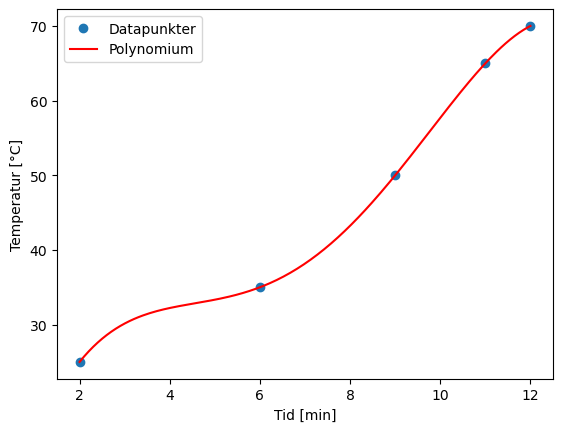

In [9]:
# Bruger samme x-værdier fra før til at bestemme nye y-værdier
y = a + b * x + c * x**2 + d * x**3 + e * x**4

fig, ax = plt.subplots()
ax.plot(data[0], data[1], 'ob', label = 'Datapunkter')
ax.plot(x, y, color = 'red', label = 'Polynomium')
ax.set_xlabel('Tid [min]')
ax.set_ylabel('Temperatur [°C]')
ax.legend()

$\pagebreak$

## (d) {-}

Da $p_{1}(x)$ og $p_{2}(x)$ kommer begge til at være på følgende form da de er tredjegradspolynomier:

$$
p(x) = a + bx + cx^{2} + dx^{3}
$$

Da punkterne funktionerne skal gennemgå kendes, kan der opstilles en ligning per koordinatpar for dem begge, hvilket svarer til seks ligninger. Eksempelvis medfører $p_{1}(2)$ følgende ligning:

$$
a_{1} + b_{1} \cdot 2 + c_{1} \cdot 2^{2} + d_{1} \cdot 2^{3} = 25
$$

Derudover kan der opstilles en ligning ud fra at deres hældning skal være det samme i $x = 9$. Hældningen kan bestemmes med den originale funktion differentieret, hvilket giver:

$$
p'(x) = b + 2cx + 3dx^{2}
$$

Dette resulterer i følgende udtryk:
$$
p_{1}'(9) = p_{2}'(9) \\
\Updownarrow \\
b_{1} + 2c_{1} \cdot 9 + 3d_{1} \cdot 9^{2} = b_{2} + 2c_{2} \cdot 9 + 3d_{2} \cdot 9^{2} \\
\Updownarrow \\
b_{1} + 18c_{1} + 243d_{1} - b_{2} - 18c_{2} - 243d_{2} = 0
$$

hvilket svarer til en syvende ligning. Det hele samlet ender ud i følgende ligningssystem skrevet ud som et matrixproukt:

$$
\begin{bmatrix}
1 & 2 & 2^{2} & 2^{3} & 0 & 0 & 0 & 0 \\
1 & 6 & 6^{2} & 6^{3} & 0 & 0 & 0 & 0 \\
1 & 9 & 9^{2} & 9^{3} & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 9 & 9^{2} & 9^{3} \\
0 & 0 & 0 & 0 & 1 & 11 & 11^{2} & 11^{3} \\
0 & 0 & 0 & 0 & 1 & 12 & 12^{2} & 12^{3} \\
0 & 1 & 18 & 243 & 0 & -1 & -18 & -243
\end{bmatrix}
\begin{bmatrix}
a_{1} \\
b_{1} \\
c_{1} \\
d_{1} \\
a_{2} \\
b_{2} \\
c_{2} \\
d_{2}
\end{bmatrix}
=
\begin{bmatrix}
25 \\
35 \\
50 \\
50 \\
65 \\
70 \\
0
\end{bmatrix}
$$

$\pagebreak$

## (e) {-}

In [10]:
# Får matricen til at blive printet ordentligt
np.set_printoptions(linewidth=np.inf)

# Opsætter matrix som beskrevet i forrige opgave
ligningsystem = np.zeros((7, 9))                                    # skabelon
ligningsystem[:3, :4] = np.vander(data[0,:3], 4, increasing=True)   # p1(x)
ligningsystem[:3, -1] = data[1,:3]                                  # y værdier til p1(x)
ligningsystem[3:6, 4:8] = np.vander(data[0,2:], 4, increasing=True) # p2(x)
ligningsystem[3:6, -1] = data[1,2:]                                 # y værdier til p2(x)

# Tilføjer differetieret ligning
ligningsystem[6] = np.array([0, 1, 2 * data[0, 2], 3 * data[0, 2]**2, 0, -1, -2 * data[0, 2], -3 * data[0, 2]**2, 0])

print(ligningsystem)

[[ 1.000e+00  2.000e+00  4.000e+00  8.000e+00  0.000e+00  0.000e+00  0.000e+00  0.000e+00  2.500e+01]
 [ 1.000e+00  6.000e+00  3.600e+01  2.160e+02  0.000e+00  0.000e+00  0.000e+00  0.000e+00  3.500e+01]
 [ 1.000e+00  9.000e+00  8.100e+01  7.290e+02  0.000e+00  0.000e+00  0.000e+00  0.000e+00  5.000e+01]
 [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00  1.000e+00  9.000e+00  8.100e+01  7.290e+02  5.000e+01]
 [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00  1.000e+00  1.100e+01  1.210e+02  1.331e+03  6.500e+01]
 [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00  1.000e+00  1.200e+01  1.440e+02  1.728e+03  7.000e+01]
 [ 0.000e+00  1.000e+00  1.800e+01  2.430e+02  0.000e+00 -1.000e+00 -1.800e+01 -2.430e+02  0.000e+00]]


$\pagebreak$

In [11]:
# Får igen ligningen ned på echelonform, dog uden print for at spare plads
echelon = np.copy(ligningsystem)

echelon[[1,6], :] = echelon[[6,1], :]   # R1 <-> R6
echelon[2, :] -= echelon[0, :]          # R2 -> R2 - R0
echelon[2, :] -= 7 * echelon[1, :]      # R2 -> R2 - 7R1
echelon[2, :] *= 1/echelon[2, 2]        # R2 -> -1/49 * R2
echelon[[3,6], :] = echelon[[6,3], :]   # R3 <-> R6
echelon[3, :] -= echelon[0, :]          # R3 -> R3 - R0
echelon[3, :] -= 4 * echelon[1, :]      # R3 -> R3 - 4R1
echelon[3, :] += 40 * echelon[2, :]     # R3 -> R3 + 4R2
echelon[3, :] *= 1/echelon[3, 3]        # R3 -> 1/36 * R3
echelon[5, :] -= echelon[4, :]          # R5 -> R5 - R4
echelon[6, :] -= echelon[4, :]          # R6 -> R6 - R4
echelon[6, :] += 2 * echelon[5, :]      # R6 -> R6 + 2R5
echelon[6, :] *= 1/echelon[6, 6]        # R6 -> -1/6 * R6

print(echelon)

[[ 1.00000000e+00  2.00000000e+00  4.00000000e+00  8.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  2.50000000e+01]
 [ 0.00000000e+00  1.00000000e+00  1.80000000e+01  2.43000000e+02  0.00000000e+00 -1.00000000e+00 -1.80000000e+01 -2.43000000e+02  0.00000000e+00]
 [-0.00000000e+00 -0.00000000e+00  1.00000000e+00  2.00000000e+01 -0.00000000e+00 -1.42857143e-01 -2.57142857e+00 -3.47142857e+01 -5.10204082e-01]
 [ 0.00000000e+00  0.00000000e+00 -1.97372982e-16  1.00000000e+00  0.00000000e+00 -4.76190476e-02 -8.57142857e-01 -1.15714286e+01 -2.89115646e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00  1.10000000e+01  1.21000000e+02  1.33100000e+03  6.50000000e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00  2.30000000e+01  3.97000000e+02  5.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00  3.2

Her kan det ses, at række 6 ikke har formen $[0\; 0 \dots 0 \mid 1]$, hvilket betyder at der må være mindst en løsning. Derudover vides det, at matricen ikke er kvadratisk, hvilket betyder at der kommer til at forekomme frie variabler. Der vil derfor være uendelige mange løsninger, hvilket er mere end én løsning.

$\pagebreak$

## (f) {-}

For at få en passende værdi til hældningen af punktet i $x=2$ kan man numerisk differentiere det punkt og punktet efter, da det er den tættest liggende punkt. Det vil give følgende hældning:
$$
p_{1}'(2) = \frac{\Delta y}{\Delta x} = \frac{35 - 25}{6 - 2} = \frac{10}{4} = 2.5
$$

Indsættes dette som en løsning til den tilsvarende ligning fås følgende:
$$
p'(2) = b + 2c \cdot 2 + 3d \cdot 2^{2} \\
p'(2) = b + 4c + 12d
$$

In [12]:
# Tilføjer den nye betingelse og løser med numpy
betingelse = np.array([0, 1, 2 * data[0, 0], 3 * data[0, 0]**2, 0, 0, 0, 0, 2.5])
ligningsystem = np.vstack((ligningsystem, betingelse))

a1, b1, c1, d1, a2, b2, c2, d2 = np.linalg.solve(ligningsystem[:, :-1], ligningsystem[:, -1])

print(f"a1 = {a1}, b1 = {b1}, c1 = {c1}, d1 = {d1}, a2 = {a2}, b2 = {b2}, c2 = {c2}, d2 = {d2}")

a1 = 18.775510204081634, b1 = 3.9285714285714284, c1 = -0.5102040816326531, d1 = 0.05102040816326531, a2 = 300.71428571428567, b2 = -90.17857142857144, c2 = 9.960317460317462, d2 = -0.3373015873015874


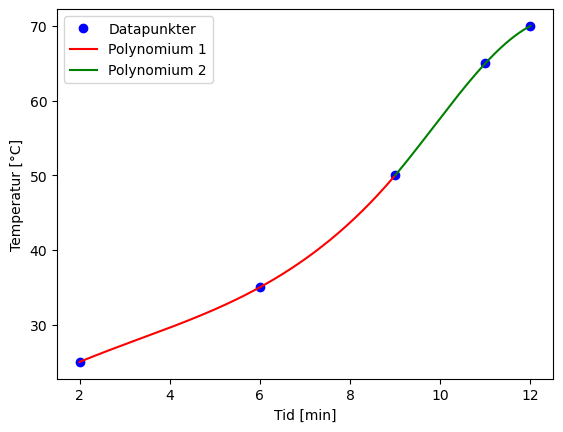

In [13]:
# Laver forskellige x-værdier for hhv. p1(x) og p2(x) (indenfor definition)
x1 = np.linspace(2, 9, n)
x2 = np.linspace(9, 12, n)

p1 = a1 + b1 * x1 + c1 * x1**2 + d1 * x1**3
p2 = a2 + b2 * x2 + c2 * x2**2 + d2 * x2**3

fig, ax = plt.subplots()
ax.plot(data[0], data[1], 'ob', label = 'Datapunkter')
ax.plot(x1, p1, color = 'red', label = 'Polynomium 1')
ax.plot(x2, p2, color = 'green', label = 'Polynomium 2')
ax.set_xlabel('Tid [min]')
ax.set_ylabel('Temperatur [°C]')
ax.legend()

## (g) {-}

Indenfor intervallet (op til 70­°C) er der ingen tvivl om at modellen fra (f) er den bedste, da den tilpasser sig bedst til ændringen af kurvens hældning i de forskellige punkter. Efter 70°C er det dog svært at sige, da data godt at svinge. Det er derfor sandsynligvis lige så godt at bruge modellen fra (c), eller måske bedre da den er nemmere at beregne. Modellen fra (b) villen nok ikke du i længden da den dykker meget hurtigere end de andre da det er et 2. grads polynomium, hvilket ikke giver mening ift. temperatur.